In [183]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import cv2
import time
import io
from IPython import display
from PIL import Image
from tqdm import tqdm

### ---- Analyse all Trajectories and delete bad ones -------

In [202]:
def show_all_plots(plots_base, plot_tag='sim_pos_xy'):
    plots_folders = sorted(os.listdir(plots_base))
    for i in range(0, len(plots_folders), 25):
        fig, axes = plt.subplots(5, 5, figsize=(20, 20))
        for j in range(5):
            for k in range(5):
                if i+j*5+k >= len(plots_folders):
                    break
                run = plots_folders[i+j*5+k]
                splots = [sp for sp in os.listdir(os.path.join(plots_base, run)) if sp.startswith(plot_tag)]
                if not splots:
                    print(f"Skipping {run}")
                    continue
                im_path = os.path.join(plots_base, run, splots[0])
                axes[j, k].imshow(plt.imread(im_path))
                axes[j, k].set_title(run)
        plt.show()

In [185]:
def delete_datas(dataset_base, plots_base, bad_runs):
    for run in bad_runs:
        run_type = run[1:].split('_')
        run_type = run_type[0] + '_' + run_type[1][1:]
        shutil.rmtree(os.path.join(plots_base, run))
        if os.path.exists(os.path.join(dataset_base, 'train', run_type, run[1:])):
            shutil.rmtree(os.path.join(dataset_base, 'train', run_type, run[1:]))
        elif os.path.exists(os.path.join(dataset_base, 'eval', run_type, run[1:])):
            shutil.rmtree(os.path.join(dataset_base, 'eval', run_type, run[1:]))

        print(f"Deleted {run}")

In [203]:
def watch_videos(plots_base, speed=16.0, wait_time=0.7):
    plots_folders = sorted(os.listdir(plots_base))
    for pi, pfldr in enumerate(plots_folders):
        video_name = [f for f in os.listdir(os.path.join(plots_base, pfldr)) if f.endswith('.mp4')]
        if len(video_name) == 0:
            print(f"Skipping {pfldr}")
            continue
        video_name = video_name[0]
        video_path = os.path.join(plots_base, pfldr, video_name)
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open video {video_path}")
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        for fc in range(total_frames):
            ret, frame = cap.read()
            if not ret:
                cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                continue
            cv2.putText(frame, f'Frame: {fc + 1}/{total_frames}', (0, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0, 255), 1)
            cv2.putText(frame, f'Video: {pi + 1}/{len(plots_folders)}', (120, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0, 255), 1)
            cv2.putText(frame, pfldr, (0, 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

            _, buffer = cv2.imencode('.jpeg', frame)
            image = Image.open(io.BytesIO(buffer))
            image = image.resize((320, 320))
            display.display(image)
            display.clear_output(wait=True)
            time.sleep(1 / speed)

        time.sleep(wait_time)
        cap.release()

Skipping left_0blue_2025_03_30_00_11_41
Skipping left_0blue_2025_03_30_00_13_02
Skipping left_0blue_2025_03_30_00_15_56


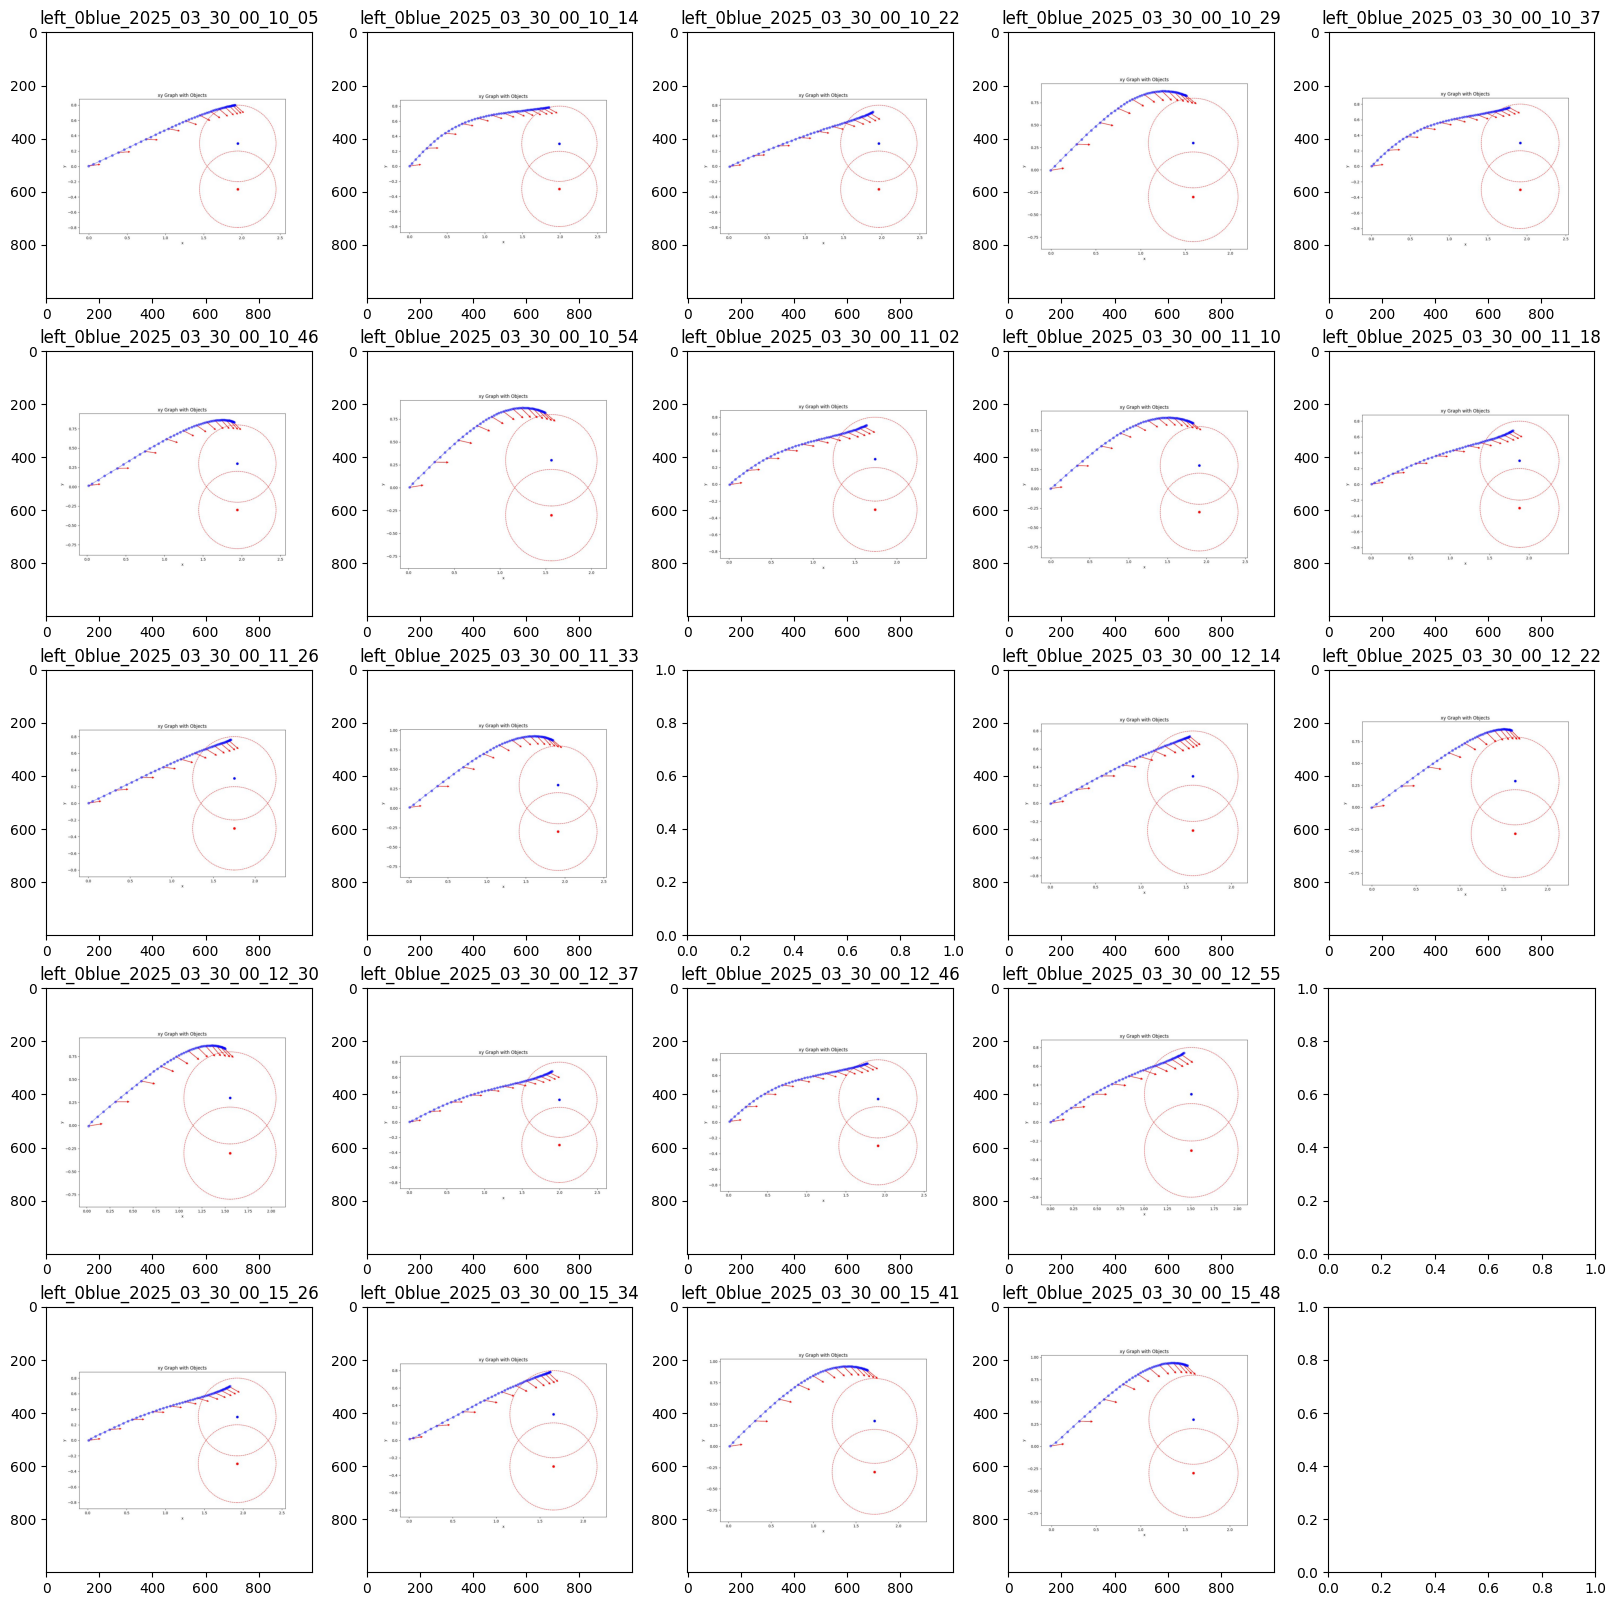

In [204]:
show_all_plots('/home/alex/flex/MCMD_Sim/results')

In [198]:
# bad_runs = [f for f in os.listdir('/home/alex/flex/MCMD_Sim/results') if f.startswith('1')]
# len(bad_runs)

In [199]:
# delete_datas('/home/alex/flex/BLIP2_DATASET', '/home/alex/flex/MCMD_Sim/results', bad_runs)

In [205]:
watch_videos('/home/alex/flex/MCMD_Sim/results', speed=20.0, wait_time=0.1)

Skipping left_0blue_2025_03_30_00_15_56


### --------Viewing and Changing instruction Text------------------

In [5]:
def get_all_texts(data_base, run_types=None):
    all_texts = {'train': {}, 'eval': {}}
    if run_types is None: run_types = os.listdir(os.path.join(data_base, 'train'))
    for run_for in ['train', 'eval']:
        for run_type in run_types:
            for run in os.listdir(os.path.join(data_base, run_for, run_type)):
                with open(os.path.join(data_base, run_for, run_type, run, 'label.txt'), 'r') as f:
                    text = f.read()
                all_texts[run_for][run] = text
    return all_texts

In [11]:
from simulator.utils.tasks import generate_instruction
def change_run_text(data_base, runs = None, command = None, color = None):
    if runs is None: runs = os.listdir(data_base)
    for run in runs:
        command, color = None, None
        run_path = os.path.join(data_base, run)
        if not os.path.exists(run_path):
            run_type = run.split('_')
            command, color = run_type[0], run_type[1][1:]
            run_type = command + '_' + color
            run_path = os.path.join(data_base, run_type, run)
        with open(os.path.join(run_path, 'label.txt'), 'r') as f:
            text = f.read()
        text = text.split(' ')
        if command is None:
            command = 'towards'
            if 'right' in text: command = 'right'
            if 'left' in text: command = 'left'
        if color is None:
            color = 'blue'
            if 'red' in text: color = 'red'
            if 'green' in text: color = 'green'
        new_text = generate_instruction(color, command)
        with open(os.path.join(run_path, 'label.txt'), 'w') as f:
            f.write(new_text)
        print(f"Changed {run} from {text} to {new_text}")

In [10]:
change_run_text('/home/alex/flex/BLIP2_DATASET/train/right')

Changed 2025_03_19_01_43_29_right from ['Avoid', 'the', 'green', 'ball', 'by', 'shifting', 'right'] to Advance on the right of green signal.
Changed 2025_03_19_02_09_15_right from ['Carefully', 'drift', 'to', 'the', 'right', 'of', 'the', 'red', 'ball'] to Rush to the right of green target.
Changed 2025_03_19_01_48_16_right from ['Circle', 'around', 'the', 'red', 'ball', 'to', 'the', 'right'] to Head to the right of green target.
Changed 2025_03_19_02_05_19_right from ['Circle', 'to', 'the', 'right', 'of', 'the', 'red', 'ball'] to Journey on the right of green symbol.
Changed 2025_03_19_01_39_49_right from ['Drift', 'to', 'the', 'right', 'of', 'the', 'red', 'ball'] to Travel on the right of green beacon.
Changed 2025_03_19_02_08_16_right from ['Glide', 'to', 'the', 'right', 'of', 'the', 'red', 'ball'] to Proceed to the right of green signal.
Changed 2025_03_19_01_55_38_right from ['Drift', 'away', 'from', 'the', 'red', 'ball', 'by', 'going', 'right'] to Proceed to the right of green des

In [38]:
get_all_texts('/home/alex/flex/Direction_Dataset')

{'train': {'right_1blue_2025_03_25_15_26_20': 'Migrate to the right of blue spot.',
  'right_1blue_2025_03_25_15_29_39': 'Rush on the right of blue symbol.',
  'right_1blue_2025_03_25_15_20_34': 'Venture to the right of blue goal.',
  'right_1blue_2025_03_25_15_24_08': 'Navigate to the right of blue goal.',
  'right_1blue_2025_03_25_15_21_01': 'Rush to the right of blue location.',
  'right_1blue_2025_03_25_15_25_46': 'Proceed to the right of blue goal.',
  'right_1blue_2025_03_25_15_27_38': 'Advance to the right of blue marker.',
  'right_1blue_2025_03_25_15_25_03': 'Migrate to the right of blue target.',
  'right_1blue_2025_03_25_15_23_01': 'Navigate on the right of blue destination.',
  'right_1blue_2025_03_25_15_28_20': 'Venture on the right of blue goal.',
  'right_1blue_2025_03_25_15_18_47': 'Migrate on the right of blue signal.',
  'right_1blue_2025_03_25_15_26_28': 'Venture on the right of blue marker.',
  'right_1blue_2025_03_25_15_30_38': 'Move on the right of blue marker.',


### ---------------Convert to features -----------------------

In [26]:
import os
import torch
import random
import numpy as np
from tqdm import tqdm
from PIL import Image
import sys
sys.path.append('/home/alex/flex/learning/src/models/components/extractors')
from blip import BLIPExtractor # type: ignore
from torchvision import transforms # type: ignore

/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/fairscale/experimental/nn/offload.py:19: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_fwd(orig_func)  # type: ignore
/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/fairscale/experimental/nn/offload.py:30: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_bwd(orig_func)  # type: ignore


In [ ]:
# ----------------- SEED FUNCTION -----------------
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)

# ----------------- DATA to BLIP FUNCTION -----------------
def data2BLIP(model, data_path, target_path, device):
    run_types = sorted(os.listdir(data_path))
    for run_type in run_types[:-1]:
        print(f"Processing {run_type}")
        if run_type.startswith('save'): continue
        runs = sorted(os.listdir(os.path.join(data_path, run_type)))
        for i, run in tqdm(enumerate(runs)):
            target_path_run = os.path.join(target_path, run_type, run)
            os.makedirs(target_path_run, exist_ok=True)

            run = os.path.join(data_path, run_type, run)
            with open(os.path.join(run,  'label.txt'), 'r') as f:
                text = f.read()

            image_names = sorted([f for f in os.listdir(run) if f.endswith('.png')])
            run_loop = tqdm(enumerate(image_names), total=len(image_names), desc=f"Run {i+1}/{len(runs)}", leave=False)
            for j, im_name in run_loop:
                img = Image.open(os.path.join(run, im_name))
                img = img.convert('RGB')
                img = img.resize((224, 224))
                img = transforms.ToTensor()(img)
                data_out = model({"image": img.to(device), "text":text})
                # print("sanity_check", data_out.shape)
                torch.save(data_out.cpu(), os.path.join(target_path_run, im_name.replace('.png', '.pt')))
                run_loop.set_postfix({'Image': im_name})

In [31]:
data_path:str = '/home/alex/flex/BLIP2_DATASET/'
target_dir:str = "/home/alex/flex/BLIP2_Features/"
device = torch.device('cuda:0')
set_seed(42)

model = BLIPExtractor(
        'blip2_feature_extractor',
        'pretrain',
        freeze_blip=True,
        use_low_dim_feature=False,
        last_linear_layer=None,      #features before last linear layer
        use_continuous_pe=False,
        stride=14,
        checkpoint='~/.cache/torch/hub/checkpoints/blip2_pretrained.pth',
        patch_size=2,
        all_q_dims= False,
        use_masked_patch_wise_feature= True,
        use_visual_encoder_only= False
    )

model.to(device)
model.eval()
data2BLIP(model, data_path+'train/', target_dir+'train/', device)
data2BLIP(model, data_path+'eval/', target_dir+'eval/', device)

/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/alex/miniconda3/envs/flex/lib/python3.9/site-packages/lavis/models/eva_vit.py:437: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowliste

Processing left_blue


Run 191/191: 100%|██████████| 73/73 [00:04<00:00, 14.73it/s, Image=00005759.png]


Processing left_red


Run 183/183: 100%|██████████| 71/71 [00:04<00:00, 14.58it/s, Image=00005599.png]


...

Run 27/27: 100%|██████████| 73/73 [00:05<00:00, 14.51it/s, Image=00005759.png]


Processing right_blue


Run 14/14: 100%|██████████| 53/53 [00:03<00:00, 14.66it/s, Image=00004159.png]


Processing right_red


Run 11/11: 100%|██████████| 64/64 [00:04<00:00, 14.37it/s, Image=00005039.png]


### ------- Trajectory Math -----------

In [9]:
from simulator.utils import  SimUtils
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from simulator.utils.logger import SimLogger
from simulator.components.simobjects import SimObject

In [95]:
def calc_ang(ref, P1, P2):
    v1 = P1[:2] - ref[:2]
    v2 = P2[:2] - ref[:2]
    ang = np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
    return ang

def ang_xy(v1, v2):
    v1, v2 = v1[:2], v2[:2]
    ang = np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
    return ang

In [16]:
def plot_trajectory(pos_data, yaw_data, theta_env, objs=None):        
    pos_id = {'x': 0, 'y':1, 'z':2}
    for i, sbplt in enumerate(['xy', 'yz', 'xz']):
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.plot(pos_data[:, pos_id[sbplt[0]]], pos_data[:, pos_id[sbplt[1]]], marker='o', alpha=0.5, color='blue')
        if sbplt == 'xy':
            for i in range(0, yaw_data.shape[0], 5):
                x, y = pos_data[i, pos_id['x']], pos_data[i, pos_id['y']]
                ang = yaw_data[i] - theta_env + 2* np.pi
                dx, dy = 0.13 * np.cos(ang), 0.13 * np.sin(ang)
                ax.arrow(x, y, dx, dy, head_width=0.02, head_length=0.02, color='red')
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel(sbplt[0])
        ax.set_ylabel(sbplt[1])
        ax.set_title(f'{sbplt} Graph with Objects')
        if objs is not None:
            for obj in objs:
                ax.plot(obj[sbplt[0]], obj[sbplt[1]], obj['style'])
                circle = Circle((obj[sbplt[0]], obj[sbplt[1]]), 0.5, color='red', fill=False, linestyle='--')
                ax.add_patch(circle)
        fig.show()
        # plt.close(fig)

    fig, ax = plt.subplots()
    ax.plot(yaw_data)
    ax.set_ylabel('Yaw')
    fig.show()

In [165]:
class SimAnalyzer:
    def __init__(self, traj_path):
        self.traj_path = traj_path
        init_cond = json.loads(open(os.path.join(traj_path, 'init_conditions.json'), 'r').read())
        self.theta_offset = init_cond["theta_offset"]
        self.theta_env = init_cond["theta_environment"]
        self.objs = [
            SimObject(loc_xy, self.theta_env, colr, obj_type) 
            for loc_xy, colr, obj_type in zip(
                init_cond['objects_loc'], 
                init_cond["objects_color"], 
                init_cond['objects_type']
            )
        ]
        self.drone = SimObject(
            init_cond['drones_loc'][0], 
            self.theta_env, 
            obj_type='drone', colr='black'
        )
        self.target = init_cond['target_idx']
        with open(os.path.join(traj_path, 'logs.txt'), 'r') as f:
            text = f.read()
        text = text.split('\n')[1].replace('(', '').split(' ')[-3:]
        self.Pd_rel = np.array([float(x[:-1]) for x in text])

In [166]:
traj_path = '/home/alex/flex/MCMD_Sim/results/left_1red_2025_03_29_21_58_48'

In [167]:
sim = SimAnalyzer(traj_path)

In [168]:
# target = 1 
# Pd_rel = np.array([Ptr[0], 0, Ptr[2]])

In [169]:
target = sim.target
Ptr = sim.objs[target].loc_rel
Pd_rel = sim.Pd_rel

In [170]:
Pt = np.array(sim.objs[target].loc_abs)
P0 = np.array(sim.drone.loc_abs)
Pd = np.array(SimUtils.convert_to_global(Pd_rel, sim.objs[1].theta))

In [180]:
n_points = 8800
c_steps = np.linspace(0, 1, n_points)
c_steps = np.column_stack([
    1 - (1 - c_steps)**3,
    1 - (1 - c_steps)**5,
    1 - (1 - c_steps)**20
])
t_yaw = np.linspace(0, 1, n_points) ** 1.6

c_dir = Pd - Pt
d_dir = Pd - P0

c_values = 0.5 * np.sin(np.pi * c_steps) 
trajectory = P0[None, :] + c_steps * d_dir[None, :] + c_values * c_dir

c_ortho = np.array([c_dir[1], -c_dir[0], 0])
sgn = np.sign(np.dot(c_ortho, d_dir))
dd = 0.8 * c_dir + 2 * c_ortho * sgn 

delta_xy = Pt[None, :2] + t_yaw[:, None] * dd[None, :2] - trajectory[:, :2]
yaw_angles = np.unwrap(np.arctan2(delta_xy[:, 1], delta_xy[:, 0]))

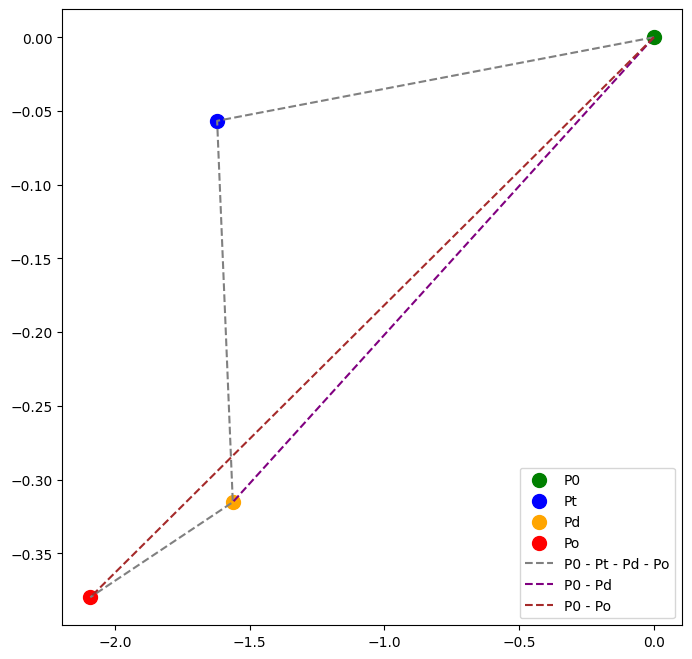

1.0

In [181]:
Po = dd + Pt
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(P0[0], P0[1], color='green', label='P0', s=100)
ax.scatter(Pt[0], Pt[1], color='blue', label='Pt', s=100)
ax.scatter(Pd[0], Pd[1], color='orange', label='Pd', s=100)
ax.scatter(Po[0], Po[1], color='red', label='Po', s=100)

ax.plot([P0[0], Pt[0], Pd[0], Po[0]], [P0[1], Pt[1], Pd[1], Po[1]], linestyle='--', color='gray', label='P0 - Pt - Pd - Po')
ax.plot([P0[0], Pd[0]], [P0[1], Pd[1]], linestyle='--', color='purple', label='P0 - Pd')
ax.plot([P0[0], Po[0]], [P0[1], Po[1]], linestyle='--', color='brown', label='P0 - Po')
# ax.plot([Po[0], Pt[0]], [Po[1], Pt[1]], linestyle='--', color='pink', label='Po to Pt')

ax.legend()

plt.show()
ang_t0d = calc_ang(P0[:2], Pt[:2], Pd[:2])
ang_t0o = calc_ang(P0[:2], Pt[:2], Po)
np.sign(ang_t0d -ang_t0o)

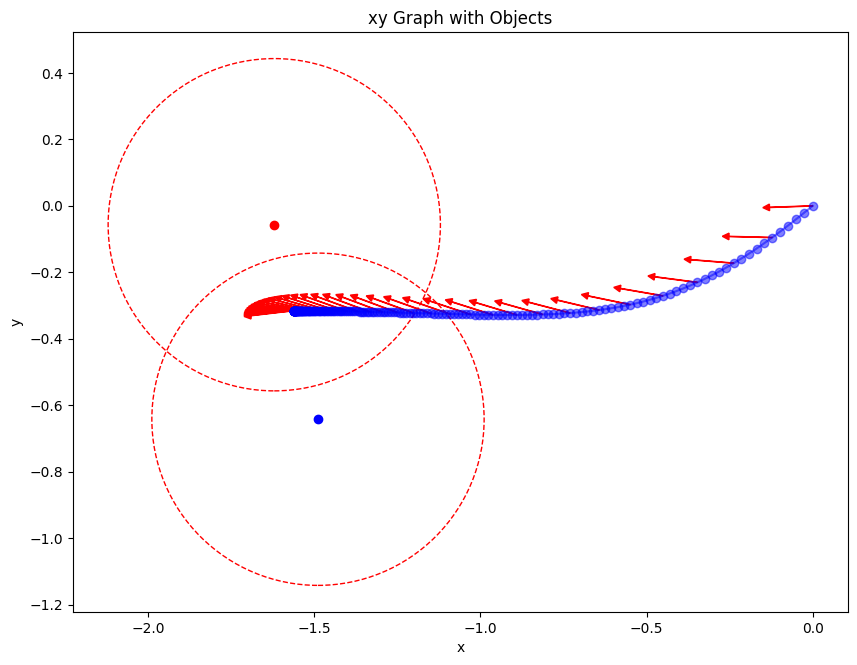

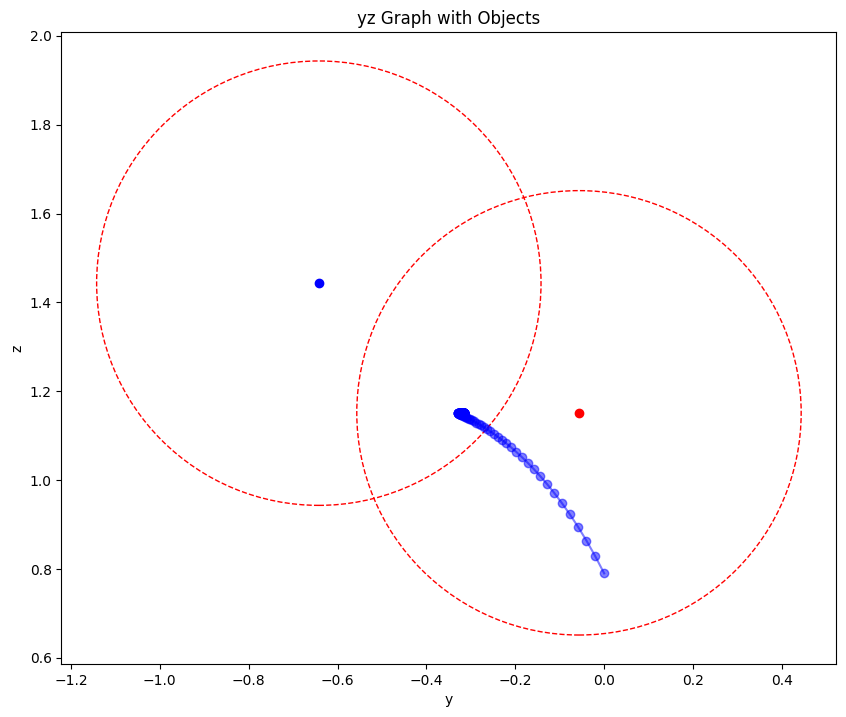

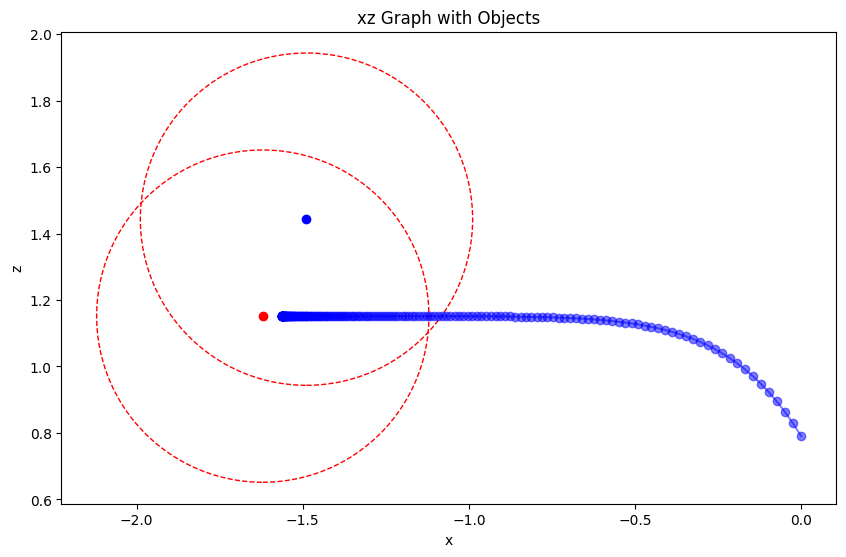

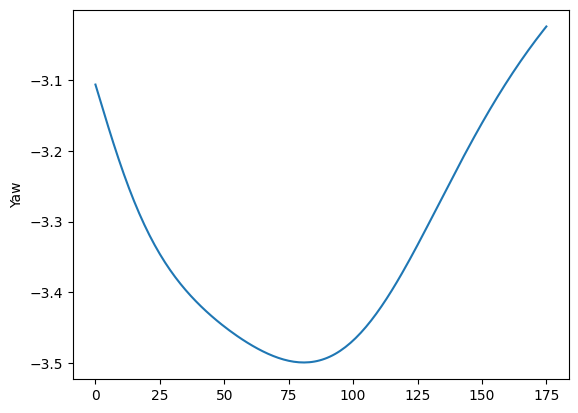

In [182]:
plot_trajectory(
    # SimUtils.traj2xyz_relative_to_base_env(trajectory[::50], sim.theta_env), 
    trajectory[::50],
    yaw_angles[::50], 
    0,
    # sim.theta_env, 
    [SimLogger.parse_obj(obj, False) for obj in sim.objs]
)

In [2]:
dataset_base = '/home/alex/flex/BLIP2_DATASET/train'
plots_base = '/home/alex/flex/MCMD_Sim/results'
run_folders = os.listdir(dataset_base)
summary_data = []

In [3]:
all_train_sf_labels = []
for run in os.listdir(os.path.join(dataset_base, 'save_flight')):
    with open(os.path.join(dataset_base, 'save_flight', run, 'label.txt'), 'r') as f:
        all_train_sf_labels.append(f.read())
with open('all_train_sf_labels.txt', 'w') as f:
    f.write('\n'.join(all_train_sf_labels))


In [5]:
all_train_sf_labels_lst = []
for sf_label in all_train_sf_labels:
    sf_label_split = sf_label.split(' ')
    for i, sf_label_wrd in enumerate(sf_label_split):
        if i >= len(all_train_sf_labels_lst): all_train_sf_labels_lst.append(set())
        all_train_sf_labels_lst[i].add(sf_label_wrd)

In [15]:
all_train_sf_labels_lst[5]

{'of', 'point.', 'target.'}

In [19]:
# for run in run_folders:
#     data_path = os.path.join(dataset_base, run, 'data_out.csv')
#     df = pd.read_csv(data_path)
#     vx, vy, vz, yr = df.iloc[:, :4].values.T
#     row_data = {
#         'run': run,
#         'vx_mean': vx.mean(),
#         'vy_mean': vy.mean(),
#         'vz_mean': vz.mean(),
#         'yr_mean': yr.mean(),
#         'vx_std': vx.std(),
#         'vy_std': vy.std(),
#         'vz_std': vz.std(),
#         'yr_std': yr.std(),
#         'total_length': len(df)
#     }
#     summary_data.append(row_data)

# summary_df = pd.DataFrame(summary_data)
    

In [18]:
# summary_df[['run', 'total_length']].sort_values('total_length', ascending=False).iloc[-15:]

In [17]:
# summary_df[['total_length']].plot(kind='line', marker='o')
# plt.title("Mean Values per Run")
# plt.show()

In [16]:
def show_all_plots(plots_base, plot_tag='sim_pos_xy'):
    plots_folders = sorted(os.listdir(plots_base))
    for i in range(0, len(plots_folders), 25):
        fig, axes = plt.subplots(5, 5, figsize=(20, 20))
        for j in range(5):
            for k in range(5):
                if i+j*5+k >= len(plots_folders):
                    break
                run = plots_folders[i+j*5+k]
                splots = [sp for sp in os.listdir(os.path.join(plots_base, run)) if sp.startswith(plot_tag)]
                im_path = os.path.join(plots_base, run, splots[0])
                axes[j, k].imshow(plt.imread(im_path))
                axes[j, k].set_title(run)
        plt.show()

In [22]:
import cv2
import IPython.display as display
from PIL import Image
import io

cap = cv2.VideoCapture('/home/alex/flex/MCMD_Sim/results/2025_03_17_12_27_38/out_video_12_27_38.mp4')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    _, buffer = cv2.imencode('.jpeg', frame)
    display.display(Image.open(io.BytesIO(buffer)))
    display.clear_output(wait=True)

cap.release()

In [23]:
import cv2
import time

def play_video(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_number = 0
    speed = 1.0  # Default speed (1x)
    paused = False
    repeat = True  # Enable repeat mode

    while True:
        if not paused:
            ret, frame = cap.read()
            if not ret:
                if repeat:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                    frame_number = 0
                    continue
                else:
                    break  # Exit when video ends

            # Display the frame number
            cv2.putText(frame, f'Frame: {frame_number}/{total_frames}', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            # cv2.imshow('Video Player', frame)
            _, buffer = cv2.imencode('.jpeg', frame)
            display.display(Image.open(io.BytesIO(buffer)))
            display.clear_output(wait=True)
            time.sleep(1 / speed)
            frame_number += 1

        # Keyboard Controls
        # key = cv2.waitKey(int(50 / speed)) & 0xFF
        # if key == ord('q'):  # Quit
        #     break
        # elif key == ord('p'):  # Pause/Resume
        #     paused = not paused
        # elif key == ord('r'):  # Restart Video
        #     cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        #     frame_number = 0
        # elif key == ord('+'):  # Increase Speed
        #     speed = min(3.0, speed + 0.1)
        # elif key == ord('-'):  # Decrease Speed
        #     speed = max(0.1, speed - 0.1)

    cap.release()
    # cv2.destroyAllWindows()


In [25]:
video_path = '/home/alex/flex/MCMD_Sim/results/left_0red_2025_03_26_16_15_41/out_video_3_26_16_15_41.mp4'  # Replace with your video path
play_video(video_path)

KeyboardInterrupt: 

In [8]:
import torch
import numpy as np
import time

In [6]:
tt = torch.randn(1, 768, 8, 8)

In [9]:
# File paths for saving
torch_file = 'tensor_torch.pt'
torch_file_compressed = 'tensor_torch_compressed.pt'
numpy_file = 'tensor_numpy.npy'
numpy_file_compressed = 'tensor_numpy_compressed.npz'

# Save the tensor using PyTorch
torch.save(tt, torch_file)
torch.save(tt, torch_file_compressed, _use_new_zipfile_serialization=True)

# Save the tensor using NumPy
np.save(numpy_file, tt.numpy())
np.savez_compressed(numpy_file_compressed, data=tt.numpy())

# Loading function with timing
def load_with_time(load_func, path):
    start = time.time()
    data = load_func(path)
    end = time.time()
    return data, end - start

# Load and measure time
torch_data, torch_time = load_with_time(torch.load, torch_file)
torch_compressed_data, torch_compressed_time = load_with_time(torch.load, torch_file_compressed)

numpy_data, numpy_time = load_with_time(lambda p: torch.from_numpy(np.load(p)), numpy_file)
numpy_compressed_data, numpy_compressed_time = load_with_time(lambda p: torch.from_numpy(np.load(p)['data']), numpy_file_compressed)

# Comparison
def compare_tensors(t1, t2):
    return torch.allclose(torch.tensor(t1), torch.tensor(t2), atol=1e-6)

print(f"Torch (Uncompressed) Load Time: {torch_time:.4f} sec")
print(f"Torch (Compressed) Load Time: {torch_compressed_time:.4f} sec")
print(f"NumPy (Uncompressed) Load Time: {numpy_time:.4f} sec")
print(f"NumPy (Compressed) Load Time: {numpy_compressed_time:.4f} sec")

print("\nData Integrity Check:")
print(f"Torch (Uncompressed) == Original: {compare_tensors(tt, torch_data)}")
print(f"Torch (Compressed) == Original: {compare_tensors(tt, torch_compressed_data)}")
print(f"NumPy (Uncompressed) == Original: {compare_tensors(tt, numpy_data)}")
print(f"NumPy (Compressed) == Original: {compare_tensors(tt, numpy_compressed_data)}")


Torch (Uncompressed) Load Time: 0.0006 sec
Torch (Compressed) Load Time: 0.0003 sec
NumPy (Uncompressed) Load Time: 0.0005 sec
NumPy (Compressed) Load Time: 0.0017 sec

Data Integrity Check:
Torch (Uncompressed) == Original: True
Torch (Compressed) == Original: True
NumPy (Uncompressed) == Original: True
NumPy (Compressed) == Original: True


/tmp/ipykernel_1227577/587070343.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = load_func(path)
/tmp/ipykernel_1227577/587070343.py:31: UserWarning: To copy con

In [48]:
start = time.time()
tt2 = torch.load('/home/alex/flex/BLIP2_Features/train/save-flight-02.13.2024_21.38.25.755537/000000a.pth', weights_only=False)
print(time.time() - start)

0.011973857879638672


In [49]:
tt2.device

device(type='cuda', index=0)

In [50]:
tt2.dtype

torch.float32

In [51]:
torch.save(tt2, 'tt2.pt')

In [52]:
torch.save(tt2.cpu(), 'tt2.pt')

In [53]:
start = time.time()
tt3 = torch.load('tt2.pt', weights_only=False, map_location='cpu')
print(time.time() - start)

0.0014536380767822266


In [54]:
(tt3.to(tt2.device) - tt2).sum()

tensor(0., device='cuda:0')

In [55]:
import os
from tqdm import tqdm

In [56]:
base_dir = '/home/alex/flex/BLIP2_Features'
new_dir = '/home/alex/flex/BLIP2_Features2'


In [57]:
l1_dir = os.listdir(base_dir)
for l1 in l1_dir:
    l2_dir = os.listdir(os.path.join(base_dir, l1))
    for l2 in tqdm(l2_dir, desc=l1):
        all_files = [f for f in os.listdir(os.path.join(base_dir, l1, l2)) if f.endswith('.pth')]
        os.makedirs(os.path.join(new_dir, l1, l2), exist_ok=True)
        for f in tqdm(all_files, desc=l2, leave=False):
            tt = torch.load(os.path.join(base_dir, l1, l2, f), weights_only=False)
            torch.save(tt.cpu(), os.path.join(new_dir, l1, l2, f.replace('.pth', '.pt')))

train: 100%|██████████| 270/270 [02:51<00:00,  1.57it/s]
